In [1]:

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches 


import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


Finite Impulse Response (FIR) filters are digital filters which have - as the name suggests - a finite impulse response. 
These filters do not have an internal feedback and can be applied simply by convolving an input sequence $x[n]$ with the filter's impulse response $h[n]$ to get the output sequence $y[n]$.


For FIR filters, the impulse response $h[n]$ is a one-dimensional array containing the $N$ filter coefficients. The following example shows the coefficients, respectively the impulse response for a filter of the order $N=4$:

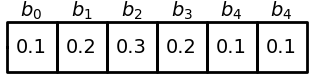

In [2]:
with schemdraw.Drawing() as d:
    d.config(unit=1, fontsize=14)

    dsp.Square().label('0.1').label('$b_0$', loc='top')
    dsp.Square().label('0.2').label('$b_1$', loc='top')
    dsp.Square().label('0.3').label('$b_2$', loc='top')
    dsp.Square().label('0.2').label('$b_3$', loc='top')
    dsp.Square().label('0.1').label('$b_4$', loc='top')
    dsp.Square().label('0.1').label('$b_4$', loc='top')

    d.draw()


-----

# The Difference Equation

The difference equation can be used for calculating the output $y[n]$ of an FIR filter.
It is a sum over the sum of all filter coefficients with the respective delayed sample of the input signal $x[n]$:

$$
y[n] = b_0 x[n] + b_1 x[n-1]+ b_2 x[n-2]+ b_3 x[n-3]+ b_4 x[n-4] + b_5 x[n-5]
$$


Or in short:

$$
  y[n] =  \sum\limits_{i=0}^{i=N} b_i  x[n-i]
$$

-----

# Implementation Structure 

Another important representation of a filter is the  implementation structure. It can be directly derived from the difference equation. Each $z^{-1}$ block represents a delay by one sample. This case shows the direct canonical form:

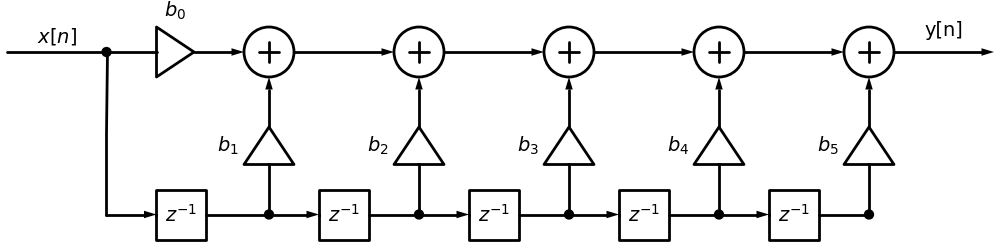

In [3]:
with schemdraw.Drawing() as d:
    d.config(unit=1, fontsize=14)

    e.Line().length(2).label('$x[n]$')
    e.Dot()
    d.push()
    e.Line()
    dsp.Amp().label('$b_0$')
    e.Arrow()
    dsp.Sum()
    e.Arrow().length(2)
    dsp.Sum()
    e.Arrow().length(2)
    dsp.Sum()
    e.Arrow().length(2)
    dsp.Sum()
    e.Arrow().length(2)
    dsp.Sum()
    e.Arrow().label('y[n]').length(2)

    d.pop()
    e.Line().down().length(3.25)
    e.Arrow().right()
    dsp.Square().label('$z^{-1}$')
    e.Line().right().length(1.25)
    e.Dot()
    
    d.push()
    
    e.Line().up().length(1)
    dsp.Amp().label('$b_1$')
    e.Arrow()
    
    d.pop()

    e.Arrow().right()
    dsp.Square().label('$z^{-1}$')
    e.Line().right().length(1)
    e.Dot()
    
    d.push()
    
    e.Line().up().length(1)
    dsp.Amp().label('$b_2$')
    e.Arrow()
    
    d.pop()

    e.Arrow().right()
    dsp.Square().label('$z^{-1}$')
    e.Line().right().length(1)
    e.Dot()
    
    d.push()
    
    e.Line().up().length(1)
    dsp.Amp().label('$b_3$')
    e.Arrow()
    
    d.pop()

    e.Arrow().right()
    dsp.Square().label('$z^{-1}$')
    e.Line().right().length(1)
    e.Dot()
    
    d.push()
    
    e.Line().up().length(1)
    dsp.Amp().label('$b_4$')
    e.Arrow()
    
    d.pop()

    e.Arrow().right()
    dsp.Square().label('$z^{-1}$')
    e.Line().right().length(1)
    e.Dot()
    
    d.push()
    
    e.Line().up().length(1)
    dsp.Amp().label('$b_5$')
    e.Arrow()
    
    d.pop()
    
    

-----

## Applying a Filter by Convolution

Applying the filter with the given impulse response is done by simple convolution, which is the same as passing samples from the input of the implemtation structure above to its output.
The above equation is then written as follows:


$$
\begin{eqnarray}
y[m] &=& x[n] * h[m]\\
     &=& \sum\limits_{m=0}^{M} h[m] x(n-m)\\
     &=& \sum\limits_{m=0}^{M} b_m x(n-m)\\
\end{eqnarray}
$$

-----

## The Transfer Function




$$
H(z) = 0.5 z^{-2} +  z^{-3} + 0.5 z^{-4}  
$$


In the next step, all exponents are shifted by expanding with $z^{4}$:

$$
H(z) = \frac{z^2 + 2z + 1}{z^4}
$$



Factor the denominator to find its roots:


$$
H(z) = \frac{(z+1)(z+1)}{z^4}
$$

**There is a double zero at $\mathbf{z=-1}$**.
As all causal FIR filters it has $N=4$ poles at the origin $z=0$.

With $z=e^{j\omega}$ the complex roots can be obtained:

$$
Z = (e^{-i\omega} +1)(e^{-i\omega} +1)
$$

----

# In the Unit Cirlce

An LTI system can be visualized in the z-plane by plotting the zeros, respectively the roots of its impulse response. 


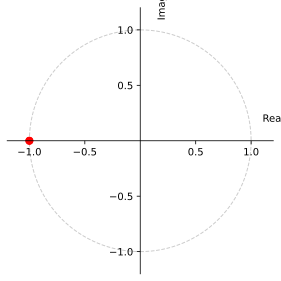

In [4]:
h = np.array([0,0.5,1,0.5,0])

b = [1,2,1]
a = [4,0,0,0,0]

ax = plt.subplot(111)
ax.axis('equal')

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.2; 
plt.axis('scaled'); 
plt.axis([-r, r, -r, r]);
ticks = [-1, -.5, .5, 1]; 
plt.xticks(ticks); 
plt.yticks(ticks);
    
uc = patches.Circle((0,0), radius=1, fill=False,
                        color= [0.8,0.8,0.8], ls='dashed');
ax.add_patch(uc);

# zeros
z  = np.roots(b);

#print('Zeros = '+str(z))

t1 = plt.plot(z.real, z.imag, 'ro', ms=7);


plt.xlabel('Real');
plt.ylabel('Imag');
ax.xaxis.set_label_coords(1,   0.6);
ax.yaxis.set_label_coords(0.6, 1);

## Frequency Response

The frequency response of the filter 


In [5]:
w, H = signal.freqz(b,a)
       
plt.plot(w, 20 * np.log10(abs(H)), color=[0.7,0.7,0.7]);
plt.xlabel('$\omega$');
plt.ylabel('$|H(\omega)|$');

#imp = signal.unit_impulse(100, 'mid')
#response = signal.lfilter(b, a, imp)

#plt.figure();
#plt.plot(response, color=[0.7,0.7,0.7]);

NameError: name 'signal' is not defined